<a href="https://colab.research.google.com/github/anubhavsingh23906-code/house-price-prediction/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import pandas as pd
import numpy as np

In [73]:
df = pd.read_csv('train (1).csv')

In [74]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [75]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [76]:
df['Fence'].describe()

,Fence
count,281
unique,4
top,MnPrv
freq,157


In [77]:
df = df.iloc[:,1:]

In [78]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [80]:
import matplotlib.pyplot as plt

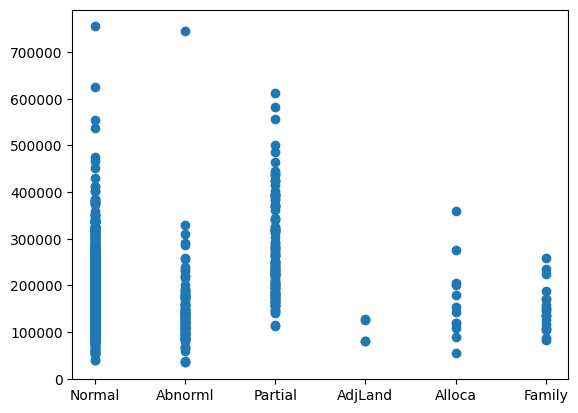

In [81]:
plt.scatter(df['SaleCondition'],df['SalePrice'])

In [82]:
df.isnull().sum().sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [83]:
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
...,...
MoSold,0.000000
YrSold,0.000000
SaleType,0.000000
SaleCondition,0.000000


In [84]:
df.drop(["PoolQC","Alley", "Fence"], axis=1, inplace=True)

In [85]:
(df.isnull().mean()*100).sort_values(ascending=False).head(20)

,0
MiscFeature,96.301370
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageFinish,5.547945
GarageQual,5.547945
GarageCond,5.547945
GarageType,5.547945
GarageYrBlt,5.547945
BsmtExposure,2.602740


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Normal'),
  Text(1, 0, 'Abnorml'),
  Text(2, 0, 'Partial'),
  Text(3, 0, 'AdjLand'),
  Text(4, 0, 'Alloca'),
  Text(5, 0, 'Family')])

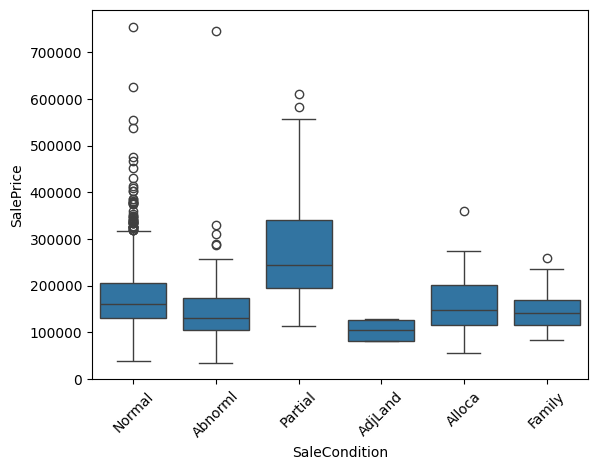

In [86]:
import seaborn as sns

sns.boxplot(x='SaleCondition', y='SalePrice', data=df)
plt.xticks(rotation=45)

In [87]:
missing = (df.isnull().sum() / len(df)) * 100
missing = missing.sort_values(ascending=False)
print(missing.head(20))

MiscFeature     96.301370
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
GarageType       5.547945
GarageYrBlt      5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
LandSlope        0.000000
Condition2       0.000000
Condition1       0.000000
Neighborhood     0.000000
dtype: float64


In [88]:
df.drop(["MiscFeature"], axis=1, inplace=True)

In [89]:
df.shape

(1460, 76)

In [90]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Numerical: 37
Categorical: 39


In [91]:
df[num_cols].isnull().sum().sort_values(ascending=False).head(10)

,0
LotFrontage,259
GarageYrBlt,81
MasVnrArea,8
MSSubClass,0
LotArea,0
OverallCond,0
OverallQual,0
YearRemodAdd,0
YearBuilt,0
BsmtFinSF2,0


In [92]:
df[cat_cols].isnull().sum().sort_values(ascending=False).head(10)

,0
MasVnrType,872
FireplaceQu,690
GarageQual,81
GarageType,81
GarageFinish,81
GarageCond,81
BsmtFinType2,38
BsmtExposure,38
BsmtCond,37
BsmtQual,37


<Axes: xlabel='LotFrontage', ylabel='Count'>

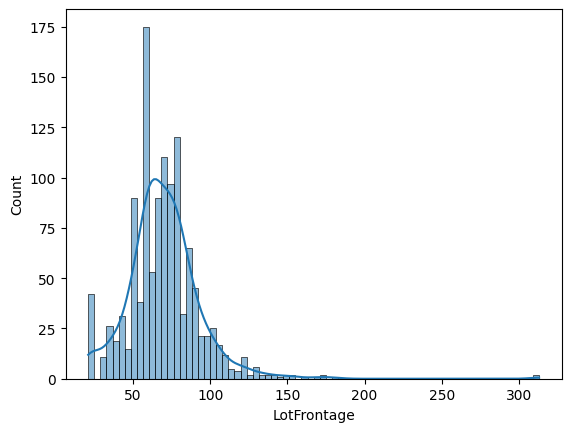

In [93]:
import seaborn as sns

sns.histplot(df['LotFrontage'], kde=True)

The LotFrontage distribution is positively skewed with several high-value outliers. Since the mean would be influenced by these extreme values, missing values will be imputed using the median.**bold text**

<Axes: xlabel='GarageYrBlt', ylabel='Count'>

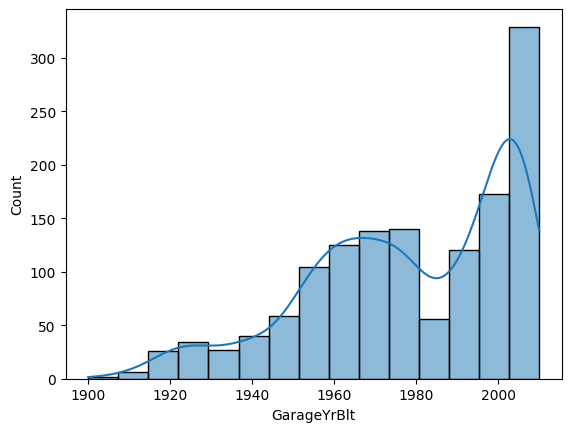

In [94]:
sns.histplot(df['GarageYrBlt'], kde=True)

<Axes: xlabel='MasVnrArea', ylabel='Count'>

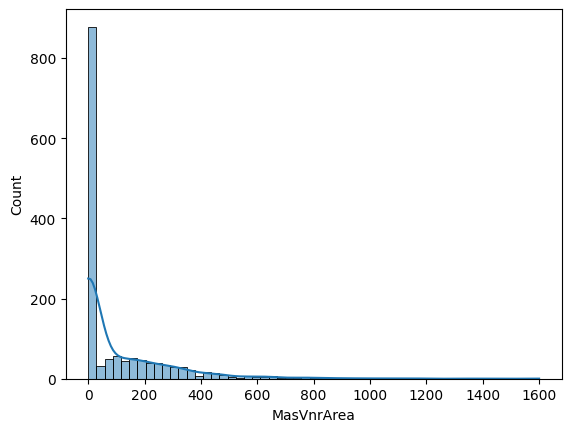

In [95]:
sns.histplot(df['MasVnrArea'], kde=True)

In [96]:
df['MasVnrArea'].mean()

np.float64(103.68526170798899)

In [97]:
df['MasVnrArea'].median()

0.0

In [98]:
df['GarageYrBlt'].mean()

np.float64(1978.5061638868744)

In [99]:
df['GarageYrBlt'].median()

1980.0

GarageYrBlt is not skewed and rest two are skewed.*italicized text*

In [100]:
df['LotFrontage'].fillna(df['LotFrontage'].median(), inplace=True)

df['GarageYrBlt'].fillna(df['GarageYrBlt'].mean(), inplace=True)

df['MasVnrArea'].fillna(df['MasVnrArea'].median(), inplace=True)

/tmp/ipykernel_11384/1874696022.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LotFrontage'].fillna(df['LotFrontage'].median(), inplace=True)
/tmp/ipykernel_11384/1874696022.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [101]:
df[num_cols].isnull().sum().sort_values(ascending=False).head(10)

,0
MSSubClass,0
LotFrontage,0
LotArea,0
OverallQual,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
MasVnrArea,0
BsmtFinSF1,0
BsmtFinSF2,0


In [102]:
df['MasVnrType'].value_counts(dropna=False)

,count
MasVnrType,
NaN,872
BrkFace,445
Stone,128
BrkCmn,15


"MasVnrType contained approximately 60% missing values, so I dropped it to simplify preprocessing and avoid introducing excessive uncertainty through imputation."

In [103]:
df.drop('MasVnrType', axis=1, inplace=True)

In [104]:
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols].isnull().sum().sort_values(ascending=False).head(10)

,0
FireplaceQu,690
GarageFinish,81
GarageType,81
GarageQual,81
GarageCond,81
BsmtExposure,38
BsmtFinType2,38
BsmtFinType1,37
BsmtCond,37
BsmtQual,37


In [105]:
df['FireplaceQu'].value_counts(dropna=False)

,count
FireplaceQu,
NaN,690
Gd,380
TA,313
Fa,33
Ex,24
Po,20


In [106]:
garage_cols = ['GarageQual','GarageType','GarageFinish','GarageCond']

for col in garage_cols:
    df[col].fillna('NoGarage', inplace=True)

bsmt_cols = ['BsmtFinType2','BsmtExposure','BsmtCond','BsmtQual']

for col in bsmt_cols:
    df[col].fillna('NoBasement', inplace=True)

df['FireplaceQu'].fillna('NoFireplace', inplace=True)

/tmp/ipykernel_11384/1019488829.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('NoGarage', inplace=True)
/tmp/ipykernel_11384/1019488829.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [107]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
BsmtFinType1,37
Electrical,1
MSSubClass,0
LotArea,0
Street,0
LotShape,0
LandContour,0
Utilities,0
LotConfig,0
MSZoning,0


In [108]:
df['BsmtFinType1'].fillna('NoBasement', inplace=True)

/tmp/ipykernel_11384/3925165113.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BsmtFinType1'].fillna('NoBasement', inplace=True)


In [109]:
df['Electrical'].value_counts()

,count
Electrical,
SBrkr,1334
FuseA,94
FuseF,27
FuseP,3
Mix,1


In [110]:
df['Electrical'].fillna(df['Electrical'].mode()[0], inplace=True)

/tmp/ipykernel_11384/1931642042.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Electrical'].fillna(df['Electrical'].mode()[0], inplace=True)


In [111]:
df.isnull().sum().sort_values(ascending=False).head(10)


,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
LotShape,0
LandContour,0
Utilities,0
LotConfig,0
LandSlope,0


In [112]:
df.isnull().sum().sum()

np.int64(0)

In [113]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [114]:
print(X.shape)
print(y.shape)

(1460, 74)
(1460,)


In [115]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [116]:
print(X_train.shape)
print(X_test.shape)

(1168, 74)
(292, 74)


In [117]:
num_cols = X_train.select_dtypes(
    include=['int64','float64']
).columns

cat_cols = X_train.select_dtypes(
    include=['object']
).columns

In [118]:
print(len(num_cols))
print(len(cat_cols))

36
38


In [119]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [120]:
StandardScaler()

StandardScaler()

In [121]:
OneHotEncoder(handle_unknown='ignore')

OneHotEncoder(handle_unknown='ignore')

In [122]:
X.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,61,0,0,0,0,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,42,0,0,0,0,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,35,272,0,0,0,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,84,0,0,0,0,0,12,2008,WD,Normal


In [123]:
print(cat_cols.tolist()[:])

['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


In [124]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [125]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [126]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [127]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBat...
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

In [128]:
y_pred = model.predict(X_test)

In [129]:
y_pred

array([155516.1442226 , 356322.44373774,  87319.65451946, 180186.38043531,
       318843.40155129,  71175.28819865, 237618.43604378, 146630.34635573,
        61702.79228637, 146815.67486341, 144080.85653465, 100578.23608864,
        80491.75440555, 221815.94889919, 174158.29426945, 130058.94203108,
       186235.84489574, 133838.35682217, 129168.67257667, 217214.22079541,
       159384.1297362 , 206696.04543053, 169262.85648849, 126980.16556812,
       200270.03583376, 136171.20805245, 195417.4073955 , 106942.86237335,
       176560.21470559, 200632.92137132, 153492.10000194, 278484.83872178,
       251543.63917214, 110501.96512391, 236227.31235109, 148613.33484378,
       138701.84000857, 198426.01043765, 311427.92300894, 122906.09133893,
       119846.7711269 , 219758.39894117,  99591.4281205 , 375888.71265395,
       134549.18433559, 136634.28983691,  95416.19230968, 138343.7356993 ,
       416563.70740067, 132271.13999556, 117212.63431837, 274112.88473733,
        98819.983354  , 2

In [130]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.885058290211978
MAE: 18532.932618701463


In [131]:
LinearRegression()

LinearRegression()

In [132]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [133]:
from sklearn.metrics import r2_score, mean_absolute_error

print("Random Forest")
print("R2:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))

Random Forest
R2: 0.8941930401569841
MAE: 17514.27315068493


In [134]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [135]:
print("Gradient Boosting")
print("R2:", r2_score(y_test, gb_pred))
print("MAE:", mean_absolute_error(y_test, gb_pred))

Gradient Boosting
R2: 0.8997457889289385
MAE: 17139.446045911496


In [136]:
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error

lr_r2 = r2_score(y_test, y_pred)
lr_mae = mean_absolute_error(y_test, y_pred)

rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

gb_r2 = r2_score(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'R2 Score': [
        lr_r2,
        rf_r2,
        gb_r2
    ],
    'MAE': [
        lr_mae,
        rf_mae,
        gb_mae
    ]
})

results.sort_values('R2 Score', ascending=False)

,Model,R2 Score,MAE
2,Gradient Boosting,0.899746,17139.446046
1,Random Forest,0.894193,17514.273151
0,Linear Regression,0.885058,18532.932619


In [137]:
residuals = y_test - y_pred

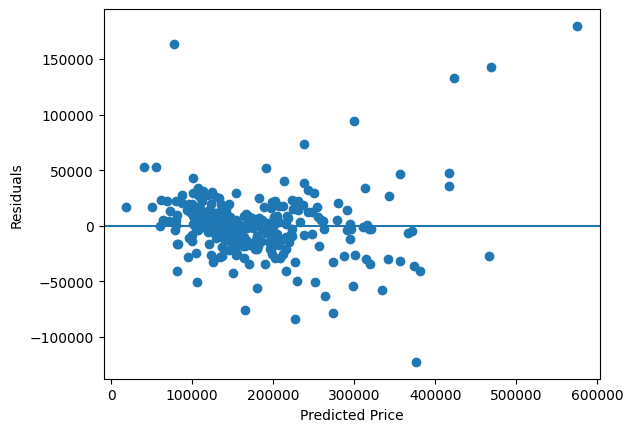

In [138]:
import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.axhline(y=0)
plt.show()

In [139]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print(scores.mean())

[0.84952941 0.82236416 0.81493091 0.88840949 0.66984598]
0.8090159896147137


In [140]:
RandomForestRegressor()

RandomForestRegressor()

In [141]:
GradientBoostingRegressor()

GradientBoostingRegressor()

In [142]:
from sklearn.metrics import r2_score, mean_absolute_error

rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest R²:", rf_r2)
print("Random Forest MAE:", rf_mae)

Random Forest R²: 0.8941930401569841
Random Forest MAE: 17514.27315068493


In [143]:
gb_r2 = r2_score(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)

print("Gradient Boosting R²:", gb_r2)
print("Gradient Boosting MAE:", gb_mae)

Gradient Boosting R²: 0.8997457889289385
Gradient Boosting MAE: 17139.446045911496


In [144]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'R2 Score': [0.885, rf_r2, gb_r2],
    'MAE': [18533, rf_mae, gb_mae]
})

print(results.sort_values('R2 Score', ascending=False))

               Model  R2 Score           MAE
2  Gradient Boosting  0.899746  17139.446046
1      Random Forest  0.894193  17514.273151
0  Linear Regression  0.885000  18533.000000


# Three regression models were evaluated for house price prediction. Gradient Boosting achieved the best performance with an R² score of 0.90 and an MAE of approximately 17,139, outperforming both Linear Regression and Random Forest.